# Deep Learning: Neural Network Regressor

This notebook is an optional extension of `modeling.ipynb`.

The idea is simple:

**final prediction = ARIMA base forecast + predicted correction**

The ARIMA forecasts were already created in `modeling.ipynb`, so I load them here instead of fitting all 70 ARIMA models again. The neural network learns the remaining error of the base model, called the **residual**.


In [1]:
import os

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")
torch.manual_seed(42)

processed = Path("../data/processed")
figures = Path("../figures")


def save(fig, name):
    fig.savefig(figures / f"{name}.png", bbox_inches="tight", dpi=150)

## 1. Data

We use the same time split as in the main modeling notebook:

- **2017:** train the neural network
- **2018:** validation and early stopping
- **2019:** final test

The saved files already contain the ARIMA base forecasts and the real sales values. We add any missing date and pair features before training.


In [2]:
def add_missing_features(df):
    df = df.copy()
    if "residual" not in df.columns:
        df["residual"] = df.number_sold - df.base
    if "pair" not in df.columns:
        df["pair"] = df.store * 10 + df["product"]
    if "day_of_week" not in df.columns:
        df["day_of_week"] = df.Date.dt.dayofweek
    if "month" not in df.columns:
        df["month"] = df.Date.dt.month
    if "day_of_year" not in df.columns:
        df["day_of_year"] = df.Date.dt.dayofyear
    return df


train_2017 = add_missing_features(pd.read_csv(processed/"base_forecast_2017.csv", parse_dates=["Date"]))
valid_2018 = add_missing_features(pd.read_csv(processed/"hybrid_predictions_2018.csv", parse_dates=["Date"]))
test_2019 = add_missing_features(pd.read_csv(processed/"hybrid_predictions_2019.csv", parse_dates=["Date"]))

features = ["store", "product", "pair", "day_of_week", "month", "day_of_year", "base"]
train_2017[features + ["residual"]].head()

,store,product,pair,day_of_week,month,day_of_year,base,residual
0,0,0,0,6,1,1,831.946908,18.053092
1,0,0,0,0,1,2,832.878148,6.121852
2,0,0,0,1,1,3,833.809450,4.190550
3,0,0,0,2,1,4,834.740525,0.259475
4,0,0,0,3,1,5,835.671084,-0.671084


## 2. Neural network

The network does **not** predict sales from zero. It predicts how much the ARIMA forecast should be corrected.

The inputs are:

- `store`, `product`, `pair` and `day_of_week` as **embeddings**.
- sine and cosine features for the position in the year, so the network can learn a smooth yearly pattern.
- the ARIMA `base` forecast, so the network knows the current sales level.

The network then uses two hidden layers, with 64 and 32 neurons and returns one number, the predicted residual. this is what we need for each combination.

So the final forecast is:

`hybrid prediction = base forecast + predicted residual`


In [3]:
NUM_STORES = 7
NUM_PRODUCTS = 10
NUM_PAIRS = 70
NUM_WEEKDAYS = 7


# Prepare the data for PyTorch 
class ResidualDataset(Dataset):
    def __init__(self, df, base_mean, base_std, target_mean, target_std):
        angle = 2 * np.pi * df.day_of_year.values / 365
        numeric = np.stack([
            np.sin(angle), np.cos(angle),
            np.sin(2 * angle), np.cos(2 * angle),
            (df.base.values - base_mean) / base_std,
        ], axis=1).astype(np.float32)

        self.store = torch.as_tensor(df.store.values, dtype=torch.long)
        self.product = torch.as_tensor(df["product"].values, dtype=torch.long)
        self.pair = torch.as_tensor(df.pair.values, dtype=torch.long)
        self.day_of_week = torch.as_tensor(df.day_of_week.values, dtype=torch.long)
        self.numeric = torch.as_tensor(numeric)
        self.target = torch.as_tensor(((df.residual.values - target_mean) / target_std).astype(np.float32))

    def __len__(self):
        return len(self.target)

    def __getitem__(self, i):
        return (self.store[i], self.product[i], self.pair[i], self.day_of_week[i],
                self.numeric[i], self.target[i])


# Small network that predicts one residual value.
class ResidualNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.store_emb = nn.Embedding(NUM_STORES, 4)
        self.product_emb = nn.Embedding(NUM_PRODUCTS, 4)
        self.pair_emb = nn.Embedding(NUM_PAIRS, 6)
        self.dow_emb = nn.Embedding(NUM_WEEKDAYS, 3)

        input_dim = 4 + 4 + 6 + 3 + 5  # embeddings + numeric features
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, store, product, pair, day_of_week, numeric):
        x = torch.cat([
            self.store_emb(store), self.product_emb(product),
            self.pair_emb(pair), self.dow_emb(day_of_week), numeric,
        ], dim=1)
        return self.net(x).squeeze(1)

## 3. Training

The base forecast and residual are standardized using the 2017 training data. This puts the values on a similar scale and makes training easier.

The network is trained on **2017** and checked on **2018** after every epoch. We use early stopping so training stops when the validation error stops improving.

The best number of epochs is saved. Later, for the final model, we train again on 2017 + 2018 for exactly that number of epochs. This means 2019 is not used to choose the model.


Best epoch: 14 of 22 trained (validation RMSE 0.7881, standardized scale)


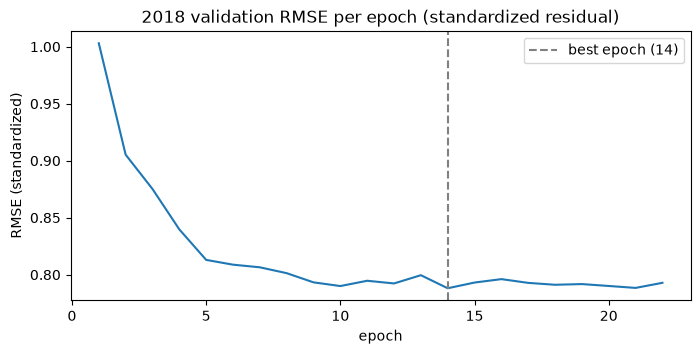

In [4]:
base_mean = train_2017.base.mean()
base_std = train_2017.base.std()
target_mean = train_2017.residual.mean()
target_std = train_2017.residual.std()

train_ds = ResidualDataset(train_2017, base_mean, base_std, target_mean, target_std)
valid_ds = ResidualDataset(valid_2018, base_mean, base_std, target_mean, target_std)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=2048, shuffle=False)


def train_with_early_stopping(train_loader, valid_loader, max_epochs=60, patience=8):
    model = ResidualNet()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.MSELoss()

    history = []
    best_state = None
    best_val = float("inf")
    best_epoch = 0
    wait = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        for store, product, pair, dow, numeric, target in train_loader:
            optimizer.zero_grad()
            loss = loss_fn(model(store, product, pair, dow, numeric), target)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            preds = torch.cat([model(*batch[:-1]) for batch in valid_loader])
            targets = torch.cat([batch[-1] for batch in valid_loader])
            val_rmse = torch.sqrt(loss_fn(preds, targets)).item()
        history.append(val_rmse)

        if val_rmse < best_val:
            best_val = val_rmse
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch, wait = epoch, 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return model, history, best_epoch


def train_fixed_epochs(train_loader, n_epochs):
    model = ResidualNet()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    loss_fn = nn.MSELoss()
    for _ in range(n_epochs):
        model.train()
        for store, product, pair, dow, numeric, target in train_loader:
            optimizer.zero_grad()
            loss = loss_fn(model(store, product, pair, dow, numeric), target)
            loss.backward()
            optimizer.step()
    return model


model, history, best_epoch = train_with_early_stopping(train_loader, valid_loader)
print(f"Best epoch: {best_epoch} of {len(history)} trained (validation RMSE {min(history):.4f}, standardized scale)")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(range(1, len(history) + 1), history, color="tab:blue")
ax.axvline(best_epoch, color="gray", linestyle="--", label=f"best epoch ({best_epoch})")
ax.set_title("2018 validation RMSE per epoch (standardized residual)")
ax.set_xlabel("epoch")
ax.set_ylabel("RMSE (standardized)")
ax.legend()
save(fig, "dl_training_curve")
plt.show()

## 4. Comparison on 2018

Now we compare the neural network with the regression models from `modeling.ipynb`: linear regression, random forest and LightGBM.

All models predict the ARIMA residual and use the same 2017 training / 2018 validation split. The neural network represents some inputs differently because it uses embeddings and sin/cosin features.


In [5]:
def predict_residual(net, df):
    ds = ResidualDataset(df, base_mean, base_std, target_mean, target_std)
    net.eval()
    with torch.no_grad():
        pred_std = net(ds.store, ds.product, ds.pair, ds.day_of_week, ds.numeric)
    return pred_std.numpy() * target_std + target_mean


valid_2018["dl_residual"] = predict_residual(model, valid_2018)
valid_2018["hybrid_dl"] = valid_2018.base + valid_2018.dl_residual

X_train = train_2017[features]
y_train = train_2017.residual
X_valid = valid_2018[features]

categories = ["store", "product", "pair", "day_of_week", "month"]
X_train_dummies = pd.get_dummies(X_train, columns=categories, dtype=float)
X_valid_dummies = pd.get_dummies(X_valid, columns=categories, dtype=float)
X_valid_dummies = X_valid_dummies.reindex(columns=X_train_dummies.columns, fill_value=0)

candidates = {
    "linear regression": LinearRegression(),
    "random forest": RandomForestRegressor(n_estimators=200, min_samples_leaf=20, n_jobs=1, random_state=42),
    "lightgbm": LGBMRegressor(n_estimators=300, learning_rate=0.05, verbose=-1, n_jobs=1, random_state=42),
}

comparison_2018 = []
for name, reg in candidates.items():
    if name == "linear regression":
        reg.fit(X_train_dummies, y_train)
        pred = reg.predict(X_valid_dummies)
    else:
        reg.fit(X_train, y_train)
        pred = reg.predict(X_valid)
    hybrid = valid_2018.base + pred
    comparison_2018.append({"model": name, "MAPE": mape(valid_2018.number_sold, hybrid) * 100,
                             "RMSE": rmse(valid_2018.number_sold, hybrid)})

comparison_2018.append({"model": "NN (PyTorch)",
                         "MAPE": mape(valid_2018.number_sold, valid_2018.hybrid_dl) * 100,
                         "RMSE": rmse(valid_2018.number_sold, valid_2018.hybrid_dl)})

comparison_2018 = pd.DataFrame(comparison_2018).sort_values("MAPE").reset_index(drop=True)
comparison_2018.round(3)

,model,MAPE,RMSE
0,NN (PyTorch),1.534,14.386
1,lightgbm,1.633,16.153
2,random forest,1.639,15.987
3,linear regression,1.784,16.831


## 5. Final test on 2019

After choosing the number of epochs using 2018, we combine the residual data from **2017 and 2018** and train the neural network again.

Then we evaluate on **2019 once**. The 2019 data was not used for training, model selection or early stopping.


In [6]:
# Final training data: 2017 + 2018 residuals.
train_final_df = pd.concat([train_2017, valid_2018], ignore_index=True)
train_final_ds = ResidualDataset(train_final_df, base_mean, base_std, target_mean, target_std)
train_final_loader = DataLoader(train_final_ds, batch_size=256, shuffle=True)

# we use the number of epochs selected on the 2018 validation year.
final_model = train_fixed_epochs(train_final_loader, best_epoch)

test_2019["dl_residual"] = predict_residual(final_model, test_2019)
test_2019["hybrid_dl"] = test_2019.base + test_2019.dl_residual

final_scores = pd.DataFrame([
    {"model": name,
     "MAPE": mape(test_2019.number_sold, test_2019[column]) * 100,
     "RMSE": rmse(test_2019.number_sold, test_2019[column]),
     "R2": r2_score(test_2019.number_sold, test_2019[column])}
    for name, column in [("base model: ARIMA + yearly waves", "base"),
                         ("hybrid: base + tuned LightGBM", "hybrid"),
                         ("hybrid: base + neural network", "hybrid_dl")]
])
final_scores.round(3)

,model,MAPE,RMSE,R2
0,base model: ARIMA + yearly waves,2.636,28.659,0.982
1,hybrid: base + tuned LightGBM,2.102,23.459,0.988
2,hybrid: base + neural network,1.892,19.334,0.992


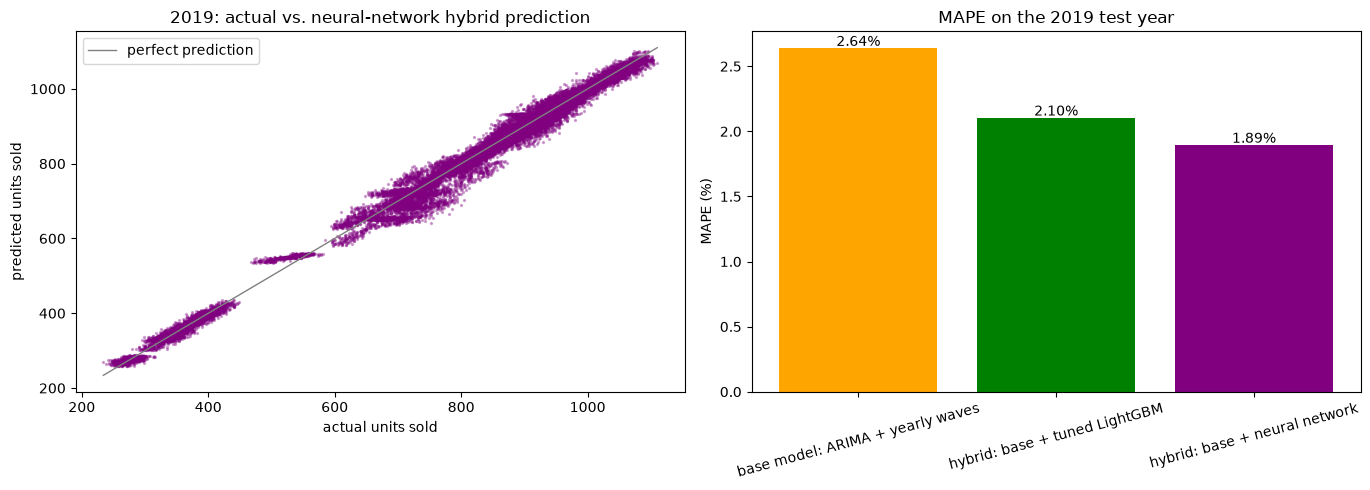

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

left = axes[0]
left.scatter(test_2019.number_sold, test_2019.hybrid_dl, s=2, alpha=0.3, color="purple")
lowest, highest = test_2019.number_sold.min(), test_2019.number_sold.max()
left.plot([lowest, highest], [lowest, highest], color="gray", linewidth=1, label="perfect prediction")
left.set_title("2019: actual vs. neural-network hybrid prediction")
left.set_xlabel("actual units sold")
left.set_ylabel("predicted units sold")
left.legend()

right = axes[1]
right.bar(final_scores.model, final_scores.MAPE, color=["orange", "green", "purple"])
right.set_title("MAPE on the 2019 test year")
right.set_ylabel("MAPE (%)")
right.tick_params(axis="x", rotation=15)
for i, value in enumerate(final_scores.MAPE):
    right.text(i, value + 0.02, f"{value:.2f}%", ha="center")

fig.tight_layout()
save(fig, "dl_test_2019_comparison")
plt.show()

## 7. Summary

### 2018 validation

| Model | MAPE | RMSE |
|---|---:|---:|
| Neural network (PyTorch) | **1.53%** | **14.4** |
| LightGBM | 1.63% | 16.2 |
| Random forest | 1.64% | 16.0 |
| Linear regression | 1.78% | 16.8 |

### 2019 final test

| Model | MAPE | RMSE | R² |
|---|---:|---:|---:|
| Base ARIMA + yearly waves | 2.64% | 28.7 | 0.982 |
| Hybrid ARIMA + tuned LightGBM | 2.09% | 23.5 | 0.988 |
| Hybrid ARIMA + neural network | **1.89%** | **19.3** | **0.992** |

### What I learned

- The neural-network hybrid gave the lowest error in this experiment.
- The network improves the ARIMA forecast by learning the errors that ARIMA leaves behind.
- 2018 was used for early stopping, while 2019 stayed untouched until the final test.
- The neural network was not tuned with Grid Search or HyperOpt, so I only treat this as an additional experiment, not proof that neural networks are always better than LightGBM.
- This result showed me that a small neural network can be useful as the second part of the hybrid model.

